Student performance prediction

Problem Understanding

We want:
👉 Predict final marks using:

study_hours

sleep_hours

phone_hours

attendance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
#calcute pridicted value
def predict(m,x,b):
  return np.dot(x, m) + b

In [ ]:
#calculate cost function
def cost_function(y, y_hat):
    y = np.array(y)
    y_hat = np.array(y_hat)
    length = len(y)
    return (1/length) * (sum((y - y_hat)**2))



In [ ]:
#calcute gradient descent
def gradient(x,y,y_hat):
  length=len(y)
  dm = (-2/length) * np.dot(x.T, (y - y_hat))
  db = (-2/length) * np.sum(y - y_hat)
  return dm,db

In [ ]:
#update slope and base value using gradient
def update(x,m,b,dm,db,alpha):
  m=m-alpha*dm
  b=b-alpha*db
  return m, b

In [ ]:
#set parameters initally
def set_parameters():
  m = np.zeros(x.shape[1])   # [0,0,0,0]
  b = 0
  return m,b

In [ ]:
#train model
#workflow->   predict value -> calculate error -> get direction (to reduce error using gradient) -> update parameters(slope(direction) , intercept(base value)) -> repeat

def train_model(x,y,alpha,iteration=20):
  m,b=set_parameters()
  loss_history=[] #it check whether the mode is improving or not
  for i in range(iteration):
    y_hat=predict(m,x,b)
    loss=cost_function(y,y_hat)
    loss_history.append(loss)
    dm,db=gradient(x,y,y_hat)
    m,b=update(x,m,b,dm,db,alpha)
  return m,b,loss_history


In [ ]:
m,b,loss=train_model(x,y,alpha=0.01,iteration=10)

In [ ]:
import pandas as pd
from io import StringIO

data = """study_hours,sleep_hours,phone_hours,attendance,marks
5,7,3,80,75
8,6,2,90,88
2,8,5,60,50
6,7,2,85,82
7,6,3,88,85
3,7,4,70,60
9,5,1,92,91
4,8,5,65,58
6,6,3,78,76
7,7,2,85,84
5,6,4,75,70
8,5,2,90,89
2,7,6,55,48
9,6,1,95,93
4,7,3,72,68
6,8,2,80,79
7,5,3,82,80
3,6,5,65,57
8,7,2,91,90
5,8,4,77,72
6,5,3,79,75
7,6,2,88,86
2,8,6,50,45
9,5,1,94,92
"""

df = pd.read_csv(StringIO(data))

print(df.head())

#pandas takes only csv files , but here we have string as a datset , so StringIO convert this string into a file like formate

   study_hours  sleep_hours  phone_hours  attendance  marks
0            5            7            3          80     75
1            8            6            2          90     88
2            2            8            5          60     50
3            6            7            2          85     82
4            7            6            3          88     85


In [ ]:
#assign features and target
x=df[['study_hours','sleep_hours','phone_hours','attendance']]
y=df['marks']


In [ ]:
#split data into test datset and train dataset
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

# apply scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)   # learn from train
x_test = scaler.transform(x_test)         # apply same scaling

In [ ]:
x_train = pd.DataFrame(x_train, columns=['study_hours','sleep_hours','phone_hours','attendance'])
x_test = pd.DataFrame(x_test, columns=['study_hours','sleep_hours','phone_hours','attendance'])

In [ ]:

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
m,b,loss_history = train_model(x_train, y_train, alpha=0.01, iteration=1000)
y_pred_custom = predict(m, x_test, b) # your model
y_pred_sklearn = model.predict(x_test) #sklearn model

In [ ]:
print(loss_history)

[np.float64(6119.105263157894), np.float64(5862.612669306247), np.float64(5618.090820165115), np.float64(5384.836246550477), np.float64(5162.202338322826), np.float64(4949.59342720216), np.float64(4746.459567187609), np.float64(4552.291926403313), np.float64(4366.61871500513), np.float64(4189.001583232392), np.float64(4019.032431947071), np.float64(3856.330585220193), np.float64(3700.5402808332083), np.float64(3551.3284400754774), np.float64(3408.382683038056), np.float64(3271.4095598164936), np.float64(3140.13297171777), np.float64(3014.292759785735), np.float64(2893.6434407740326), np.float64(2777.9530731563627), np.float64(2667.0022379158772), np.float64(2560.583120737308), np.float64(2458.4986838713016), np.float64(2360.561917380023), np.float64(2266.595160732477), np.float64(2176.429486819791), np.float64(2089.9041414248704), np.float64(2006.8660320246122), np.float64(1927.169260541489), np.float64(1850.6746953079112), np.float64(1777.249578073063), np.float64(1706.7671623778479),

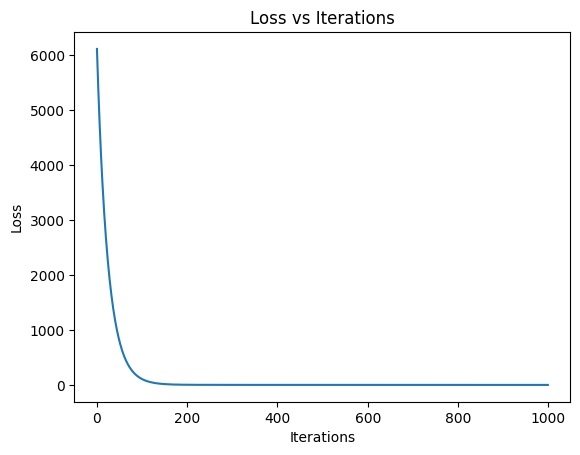

In [ ]:


plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.show()

In [ ]:
print("Custom R2:", r2_score(y_test, y_pred_custom))
print("Sklearn R2:", r2_score(y_test, y_pred_sklearn))

Custom R2: 0.9894734568893883
Sklearn R2: 0.9863350399191403


In [ ]:
print("Train Score:", model.score(x_train, y_train))
print("Test Score:", model.score(x_test, y_test))

Train Score: 0.9927886561120371
Test Score: 0.9863350399191403
